In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 1

## 1. Comparação entre DTFT e DFT

Vamos começar definindo o sinal `x[n]` e implementando as funções para calcular a DTFT e a DFT.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Definir o sinal x[n] = δ[n] − δ[n − 1] + δ[n − 2] − δ[n − 3]
x_n = np.array([1, -1, 1, -1])

def calculate_dtft(x, omega_points=1000):
    N = len(x)
    omega = np.linspace(-np.pi, np.pi, omega_points)

    dtft = np.array([
        np.sum(x * np.exp(-1j * w * np.arange(N)))
        for w in omega
    ])

    return omega, dtft

In [4]:
def calculate_dft(x, N_dft):
    # Ajuste do tamanho (zero-padding ou truncamento)
    if N_dft > len(x):
        x_padded = np.pad(x, (0, N_dft - len(x)), 'constant')
    else:
        x_padded = x[:N_dft]

    # Cálculo da DFT usando FFT
    dft = np.fft.fft(x_padded, N_dft)

    # Frequências associadas
    omega_dft = 2 * np.pi * np.fft.fftfreq(N_dft, d=1)

    # Ordenar para intervalo [-pi, pi]
    sorted_indices = np.argsort(omega_dft)

    return omega_dft[sorted_indices], dft[sorted_indices]

In [7]:
# calculo da DTFT
omega_dtft, dtft_spectrum = calculate_dtft(x_n)

# Valores de N para a DFT
Ns = [4, 16, 64, 1024]

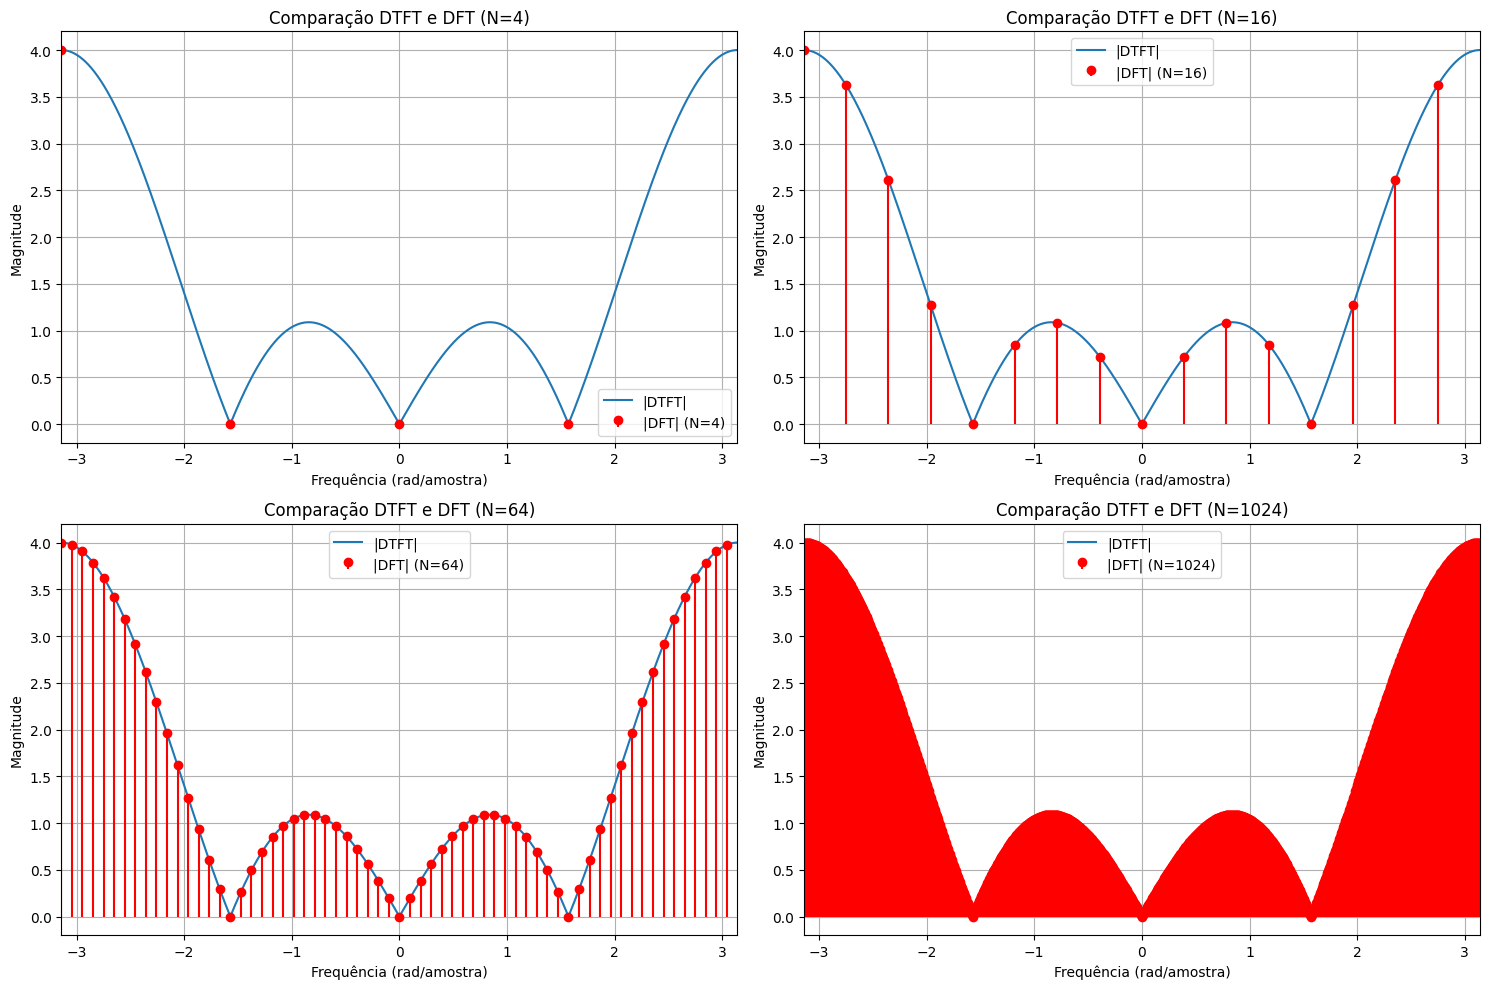

In [8]:
plt.figure(figsize=(15, 10))

for i, N in enumerate(Ns):
    omega_dft, dft_spectrum = calculate_dft(x_n, N)

    plt.subplot(2, 2, i + 1)

    # DTFT (linha contínua)
    plt.plot(omega_dtft, np.abs(dtft_spectrum), label='|DTFT|')

    # DFT (pontos discretos)
    plt.stem(omega_dft, np.abs(dft_spectrum),
             linefmt='r-', markerfmt='ro', basefmt=' ',
             label=f'|DFT| (N={N})')

    plt.title(f'Comparação DTFT e DFT (N={N})')
    plt.xlabel('Frequência (rad/amostra)')
    plt.ylabel('Magnitude')
    plt.grid(True)
    plt.legend()
    plt.xlim([-np.pi, np.pi])

plt.tight_layout()
plt.show()

### Comentários sobre os resultados da Parte 1:

Nos gráficos acima, a linha azul representa a magnitude da Transformada de Fourier de Tempo Discreto (DTFT), que é uma função contínua no domínio da frequência. Os pontos vermelhos representam a magnitude da Transformada Discreta de Fourier (DFT) para diferentes tamanhos de `N`.

Podemos observar que:

*   **N = 4:** Neste caso, o número de pontos da DFT (`N=4`) é exatamente igual ao comprimento do sinal `x[n]`. A DFT amostra a DTFT em 4 pontos de frequência discretos (0, π/2, π, 3π/2 ou 0, π/2, -π, -π/2, dependendo do mapeamento para [-π, π]). Nesses pontos, a magnitude da DFT coincide perfeitamente com a magnitude da DTFT.

*   **N = 16, 64, 1024:** À medida que `N` (o número de pontos da DFT) aumenta, a DFT amostra a DTFT em um número maior de pontos discretos e mais espaçados no domínio da frequência. Isso faz com que os pontos da DFT se aproximem cada vez mais da curva contínua da DTFT. Essencialmente, a DFT se torna uma amostragem mais fina da DTFT.

Em resumo, a DFT é uma versão amostrada da DTFT. À medida que o número de pontos `N` da DFT aumenta, a resolução da amostragem no domínio da frequência melhora, e a DFT se aproxima da representação contínua da DTFT. Para um sinal de comprimento finito `L`, se `N >= L`, a DFT de `x[n]` com zero-padding fornecerá `N` amostras da DTFT do sinal original.

In [9]:
#Exercício Prático 2

## 2. Impacto do Tamanho da DFT na Resolução

Agora vamos analisar como o tamanho da DFT e o zero-padding afetam a resolução espectral para o sinal `x(t) = sin(2πt) + sin(2, 02πt)` amostrado com `fs = 10 Hz`.

In [37]:
# Frequência de amostragem
fs = 10  # Hz

# Período de amostragem
T = 1 / fs

# Frequências dos componentes do sinal
f1 = 1.0   # Hz
f2 = 1.01  # Hz

In [38]:
#Geração do sinal
def generate_signal(num_samples):
    n = np.arange(num_samples)   # Índices
    t = n * T                    # Tempo discreto

    x_t = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

    return x_t

In [39]:
def plot_dft_spectrum(signal, N_dft, title, original_num_samples, ax):

    # Zero-padding (se necessário)
    if N_dft > len(signal):
        padded_signal = np.pad(signal, (0, N_dft - len(signal)), 'constant')
    else:
        padded_signal = signal

    # Cálculo da DFT
    dft_spectrum = np.fft.fft(padded_signal, N_dft)
    magnitudes = np.abs(dft_spectrum)

    # Frequências em Hz
    frequencies = np.fft.fftfreq(N_dft, d=T)

    # Pegar apenas frequências positivas
    positive_indices = np.where(frequencies >= 0)
    positive_frequencies = frequencies[positive_indices]
    positive_magnitudes = magnitudes[positive_indices]

    # Plot
    ax.plot(positive_frequencies, positive_magnitudes)
    ax.set_title(title)
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude |X[k]|')
    ax.grid(True)

    # Foco na região importante
    ax.set_xlim([0.9, 1.1])

    # Marcar as frequências reais
    ax.axvline(f1, linestyle='--', label=f'f1={f1} Hz')
    ax.axvline(f2, linestyle='--', label=f'f2={f2} Hz')

    ax.legend()

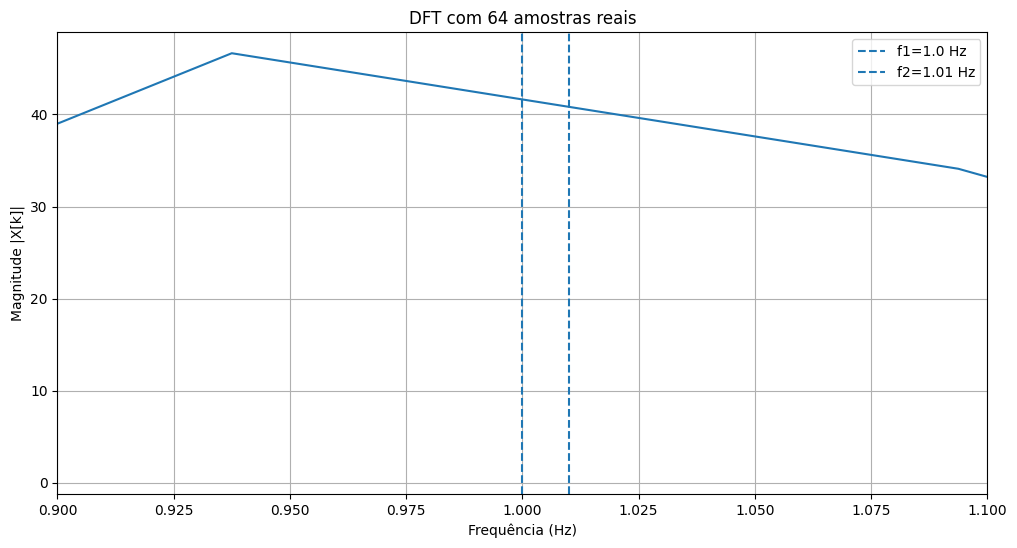

In [40]:
#64 amostras
num_samples_64 = 64
x_n_64 = generate_signal(num_samples_64)

fig, ax = plt.subplots(figsize=(12, 6))

plot_dft_spectrum(
    x_n_64,
    num_samples_64,
    f'DFT com {num_samples_64} amostras reais',
    num_samples_64,
    ax
)

plt.show()

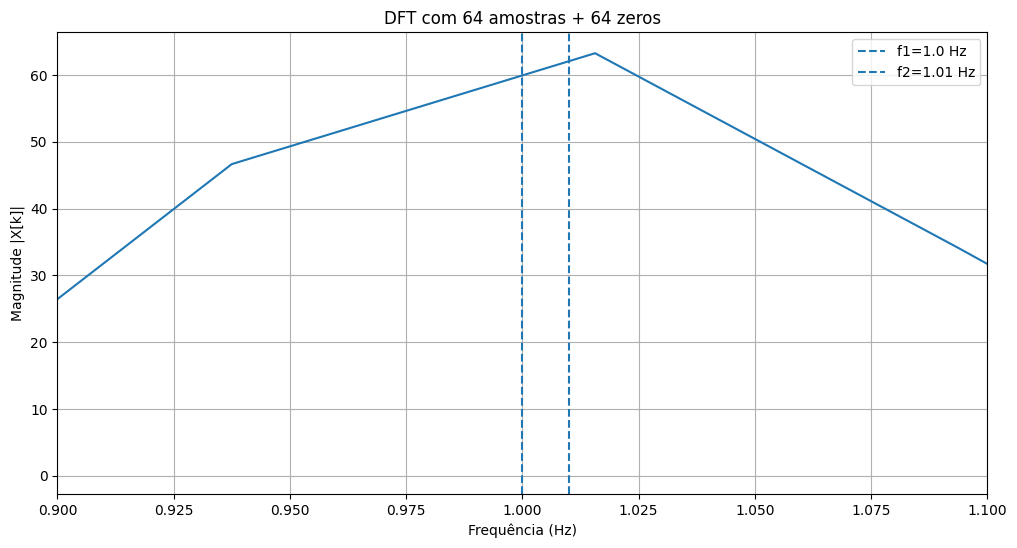

In [41]:
#64 + 64 zeros
fig, ax = plt.subplots(figsize=(12, 6))

N_dft_128_zp = 128

plot_dft_spectrum(
    x_n_64,
    N_dft_128_zp,
    f'DFT com {num_samples_64} amostras + {N_dft_128_zp - num_samples_64} zeros',
    num_samples_64,
    ax
)

plt.show()

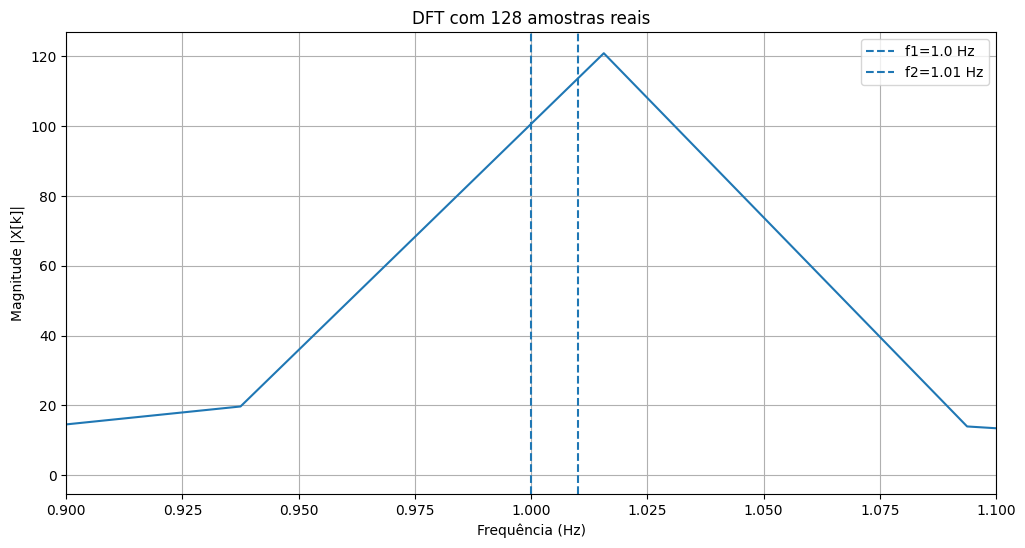

In [42]:
#128 amostras
fig, ax = plt.subplots(figsize=(12, 6))

num_samples_128 = 128
x_n_128 = generate_signal(num_samples_128)

plot_dft_spectrum(
    x_n_128,
    num_samples_128,
    f'DFT com {num_samples_128} amostras reais',
    num_samples_128,
    ax
)

plt.show()

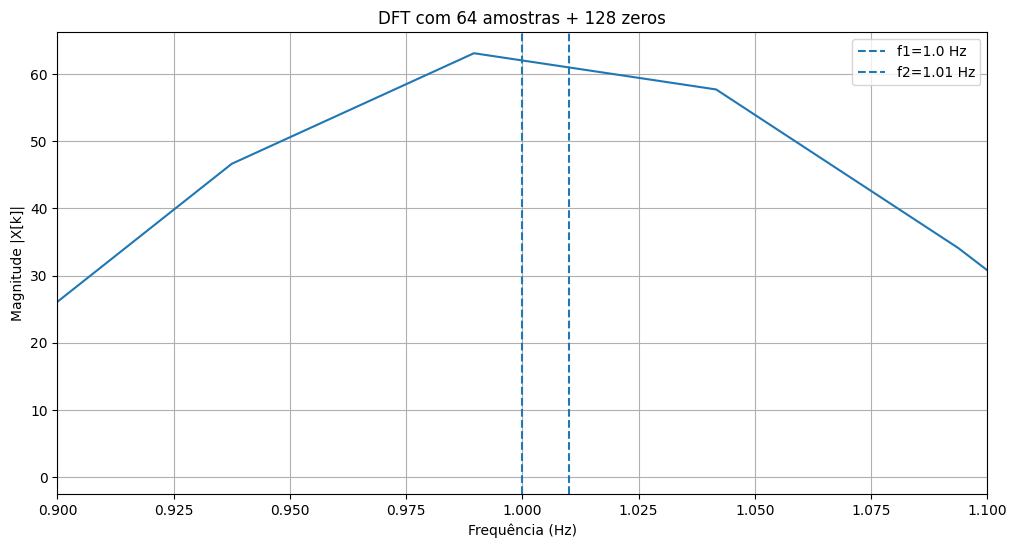

In [45]:
# 64 + 128 zeros
fig, ax = plt.subplots(figsize=(12, 6))

N_dft_192_zp = 192

plot_dft_spectrum(
    x_n_64,
    N_dft_192_zp,
    f'DFT com {num_samples_64} amostras + {N_dft_192_zp - num_samples_64} zeros',
    num_samples_64,
    ax
)

plt.show()

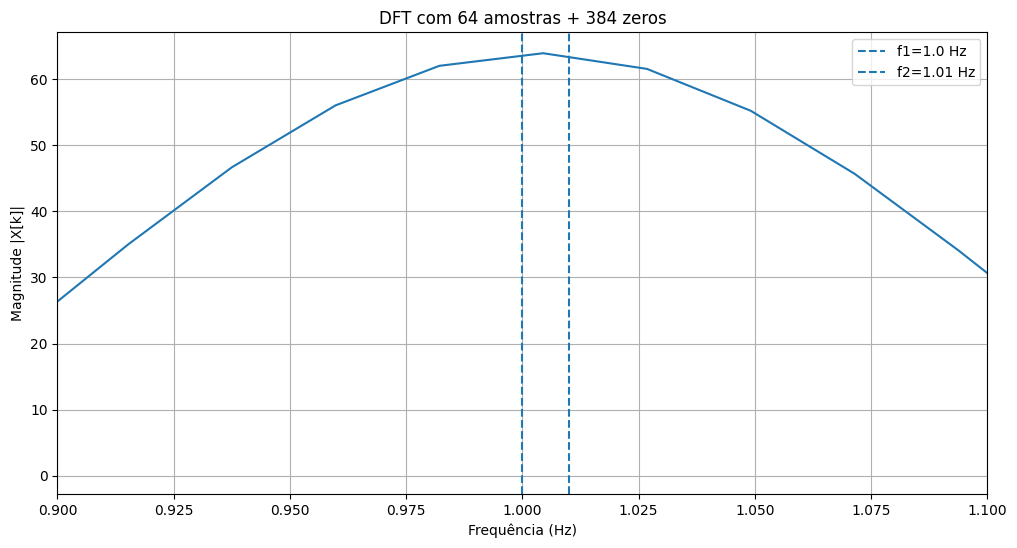

In [46]:
# 64 + 384 zeros
fig, ax = plt.subplots(figsize=(12, 6))

N_dft_448_zp = 448

plot_dft_spectrum(
    x_n_64,
    N_dft_448_zp,
    f'DFT com {num_samples_64} amostras + {N_dft_448_zp - num_samples_64} zeros',
    num_samples_64,
    ax
)

plt.show()

### Comentários sobre os resultados da Parte 2:

Vamos analisar os gráficos gerados para o sinal `x(t) = sin(2πt) + sin(2,02πt)` amostrado a `fs = 10 Hz`:

1.  **DFT com 64 amostras reais (N=64):**
    *   Observamos um único pico largo na região de 1 Hz. As duas frequências constituintes (1 Hz e 1.01 Hz) **não são distinguíveis**. Isso ocorre porque a largura do lóbulo principal da função de janela retangular (implícita pela amostragem finita) é muito grande em relação à diferença entre as frequências. A resolução espectral da DFT é inversamente proporcional ao número de amostras reais do sinal. Com apenas 64 amostras, a resolução é insuficiente para separar componentes de frequência tão próximas.

2.  **DFT com 64 amostras reais + 64 zeros (N=128):**
    *   Ao adicionar zero-padding, observamos que o pico se torna mais estreito e um pouco mais definido, mas as duas frequências ainda **não são claramente separadas**. O zero-padding aumenta o número de pontos de amostragem da DTFT (interpolação no domínio da frequência), o que nos dá uma visualização mais detalhada do espectro, mas não melhora a *resolução inerente* da DFT, que é determinada pelo tempo total de observação do sinal (o número de amostras reais). O zero-padding apenas 'suaviza' o espectro, tornando a forma do pico mais visível, mas não adiciona nova informação sobre as frequências que não foi capturada nas 64 amostras originais.

3.  **DFT com 128 amostras reais (N=128):**
    *   Neste caso, as duas frequências (1 Hz e 1.01 Hz) **tornam-se claramente distinguíveis** como dois picos distintos. Isso acontece porque aumentamos o número real de amostras do sinal de 64 para 128. Ao dobrar o número de amostras reais, dobramos o tempo de observação (`T_observacao = N_amostras / fs`). O aumento do tempo de observação resulta em uma maior resolução espectral, permitindo que a DFT separe componentes de frequência mais próximas. A resolução mínima de frequência é aproximadamente `fs / N_amostras_reais`.

4.  **Efeito de novos aumentos no tamanho da DFT por meio de zero-padding (N=192 e N=448, com 64 amostras reais):**
    *   Nos gráficos de N=192 e N=448 (com as mesmas 64 amostras reais do sinal original e zero-padding adicional), continuamos a ver o efeito de 'suavização' do espectro. Os picos se tornam cada vez mais bem definidos visualmente, mas não conseguimos separar as duas frequências de 1 Hz e 1.01 Hz. A forma do lóbulo principal do espectro da janela de 64 amostras é apenas melhor delineada por mais pontos. Independentemente de quão grande seja o `N` da DFT via zero-padding, se o número de amostras **reais** do sinal não mudar, a capacidade de distinguir frequências muito próximas não será melhorada.

### Conclusão:

*   **Resolução Espectral:** A capacidade de distinguir duas componentes de frequência próximas (resolução espectral) é determinada pelo **número de amostras reais** do sinal e, consequentemente, pelo tempo total de observação. Um maior número de amostras reais leva a uma maior resolução.

*   **Zero-padding:** O zero-padding aumenta o número de pontos da DFT, o que significa que estamos calculando mais amostras da DTFT do sinal. Isso interpola o espectro, tornando-o visualmente mais suave e detalhado. Embora possa ajudar a identificar a localização precisa de um pico existente, ele **não melhora a resolução espectral** do sinal. Ou seja, ele não nos permite distinguir frequências que já não eram distinguíveis com a DFT de menor `N` (com base no número de amostras reais).

*   **Limitações:** O zero-padding é útil para obter uma representação mais densa e suavizada do espectro, o que pode ser benéfico para a visualização ou para encontrar a frequência exata de um pico já resolvido. No entanto, ele não pode compensar a falta de informação contida no sinal original devido a um tempo de observação curto. Para melhorar genuinamente a capacidade de separar frequências próximas, é necessário amostrar o sinal por um período de tempo mais longo, ou seja, aumentar o número de amostras reais.

In [ ]:
#Exercício Prático 3

## 3. Compressão de Sinais 1-D (Áudio) com DFT e DCT

Nesta parte, vamos explorar a compressão de um sinal de áudio (`handel.wav`) usando a DFT e a Transformada de Cossenos Discreta (DCT) para diferentes fatores de compressão de energia.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from google.colab import files

print("upload o aquivo handel.wav:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"File uploaded: {filename}")

Please upload the handel.wav file:


Saving handel.wav to handel.wav
File uploaded: handel.wav


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, ifft, dct, idct
import os

In [50]:
# Carregar o sinal de áudio
fs_audio, audio_signal = wavfile.read(filename)

# Se for estéreo, usar apenas um canal
if audio_signal.ndim > 1:
    audio_signal = audio_signal[:, 0]

# Normalização
audio_signal = audio_signal.astype(np.float64)
audio_signal /= np.max(np.abs(audio_signal))

print(f"Frequência de amostragem: {fs_audio} Hz")
print(f"Duração do sinal: {len(audio_signal)/fs_audio:.2f} segundos")

Frequência de amostragem: 8192 Hz
Duração do sinal: 8.92 segundos


In [51]:
def compress_signal(signal, transform_func, inv_transform_func, compression_factor_energy):

    # 1. Transformada
    spectrum = transform_func(signal)

    # 2. Energia total
    total_energy = np.sum(np.abs(spectrum)**2)

    # 3. Energia alvo
    target_energy = total_energy * (1 - compression_factor_energy / 100.0)

    if transform_func == fft:
        N = len(signal)

        if N % 2 == 0:
            unique_coeffs = spectrum[1:N//2]
            unique_indices = np.arange(1, N//2)
        else:
            unique_coeffs = spectrum[1:(N+1)//2]
            unique_indices = np.arange(1, (N+1)//2)

        sorted_indices_unique = np.argsort(np.abs(unique_coeffs))[::-1]

        compressed_spectrum = np.zeros_like(spectrum)
        compressed_spectrum[0] = spectrum[0]

        current_energy = np.abs(spectrum[0])**2
        num_coeffs_retained = 1

        for idx_unique in sorted_indices_unique:
            original_idx = unique_indices[idx_unique]

            compressed_spectrum[original_idx] = spectrum[original_idx]
            compressed_spectrum[N - original_idx] = spectrum[N - original_idx]

            current_energy += np.abs(spectrum[original_idx])**2 * 2
            num_coeffs_retained += 2

            if current_energy >= target_energy:
                break

    elif transform_func == dct:
        magnitudes = np.abs(spectrum)
        sorted_indices = np.argsort(magnitudes)[::-1]

        compressed_spectrum = np.zeros_like(spectrum)
        current_energy = 0
        num_coeffs_retained = 0

        for idx in sorted_indices:
            compressed_spectrum[idx] = spectrum[idx]
            current_energy += magnitudes[idx]**2
            num_coeffs_retained += 1

            if current_energy >= target_energy:
                break

    else:
        raise ValueError("Transform function not supported")

    # 4. Transformada inversa
    compressed_signal = inv_transform_func(compressed_spectrum)

    if transform_func == fft:
        compressed_signal = np.real(compressed_signal)

    return compressed_signal, num_coeffs_retained

In [52]:
def calculate_mse(original, compressed):
    return np.mean((original - compressed)**2)

In [53]:
compression_factors_energy = [99.5, 99.0, 90.0, 75.0, 50.0]

results_dft = {}
results_dct = {}

In [54]:
print("\n--- Compressão com DFT ---")

for r in compression_factors_energy:
    compressed_signal_dft, num_coeffs_dft = compress_signal(audio_signal, fft, ifft, r)
    mse_dft = calculate_mse(audio_signal, compressed_signal_dft)

    results_dft[r] = {
        'num_coeffs': num_coeffs_dft,
        'mse': mse_dft
    }

    print(f"{r}% -> {num_coeffs_dft} coeficientes | MSE: {mse_dft:.4e}")


--- Compressão com DFT ---
99.5% -> 3 coeficientes | MSE: 5.9839e-02
99.0% -> 5 coeficientes | MSE: 5.9546e-02
90.0% -> 63 coeficientes | MSE: 5.4140e-02
75.0% -> 271 coeficientes | MSE: 4.5112e-02
50.0% -> 1171 coeficientes | MSE: 3.0065e-02


In [55]:
print("\n--- Compressão com DCT ---")

for r in compression_factors_energy:
    compressed_signal_dct, num_coeffs_dct = compress_signal(audio_signal, dct, idct, r)
    mse_dct = calculate_mse(audio_signal, compressed_signal_dct)

    results_dct[r] = {
        'num_coeffs': num_coeffs_dct,
        'mse': mse_dct
    }

    print(f"{r}% -> {num_coeffs_dct} coeficientes | MSE: {mse_dct:.4e}")


--- Compressão com DCT ---
99.5% -> 1 coeficientes | MSE: 5.9759e-02
99.0% -> 2 coeficientes | MSE: 5.9448e-02
90.0% -> 39 coeficientes | MSE: 5.4090e-02
75.0% -> 185 coeficientes | MSE: 4.5102e-02
50.0% -> 835 coeficientes | MSE: 3.0078e-02


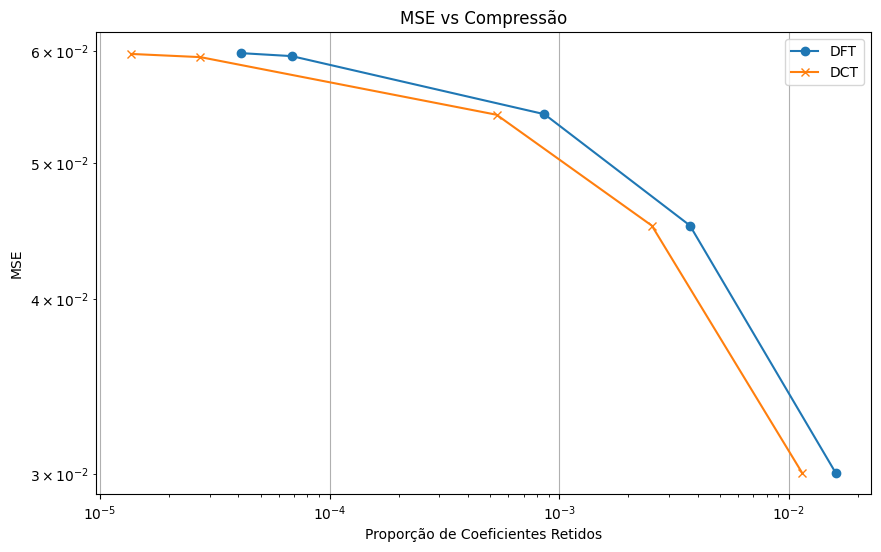

In [56]:
mse_dft_values = [res['mse'] for res in results_dft.values()]
num_coeffs_dft_values = [res['num_coeffs'] / len(audio_signal) for res in results_dft.values()]

mse_dct_values = [res['mse'] for res in results_dct.values()]
num_coeffs_dct_values = [res['num_coeffs'] / len(audio_signal) for res in results_dct.values()]

plt.figure(figsize=(10, 6))
plt.plot(num_coeffs_dft_values, mse_dft_values, 'o-', label='DFT')
plt.plot(num_coeffs_dct_values, mse_dct_values, 'x-', label='DCT')

plt.xlabel('Proporção de Coeficientes Retidos')
plt.ylabel('MSE')
plt.title('MSE vs Compressão')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

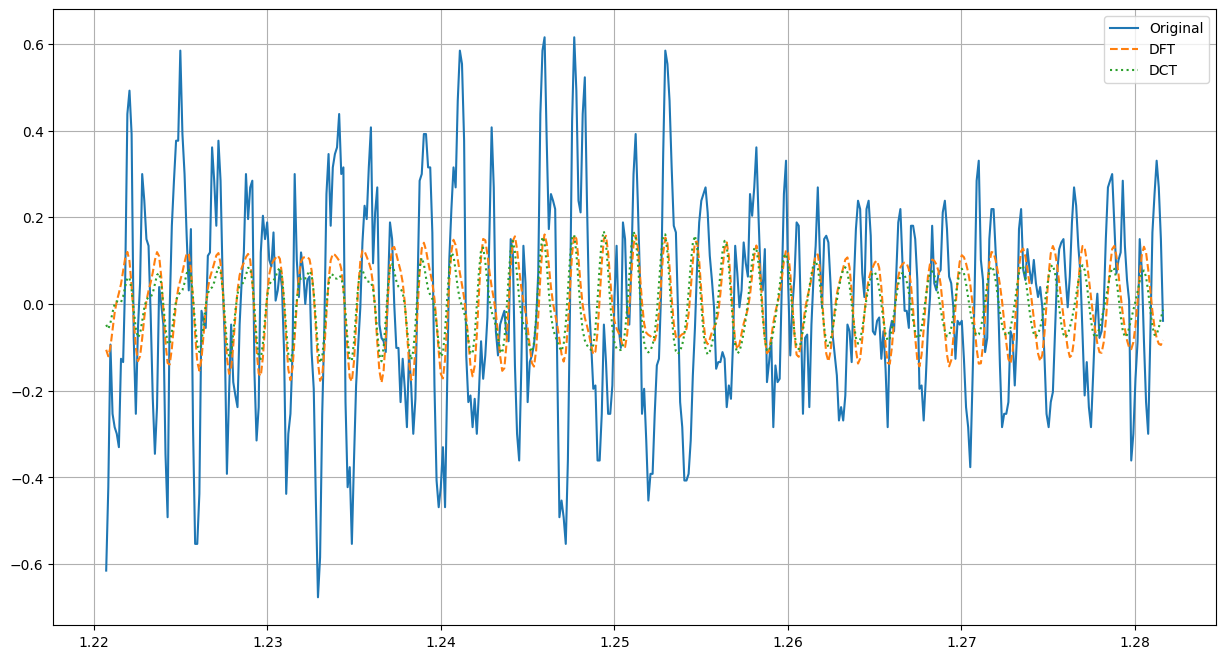

In [57]:
chosen_r = 90.0

compressed_signal_dft, _ = compress_signal(audio_signal, fft, ifft, chosen_r)
compressed_signal_dct, _ = compress_signal(audio_signal, dct, idct, chosen_r)

start_sample = 10000
end_sample = 10500

time_axis = np.arange(start_sample, end_sample) / fs_audio

plt.figure(figsize=(15, 8))
plt.plot(time_axis, audio_signal[start_sample:end_sample], label='Original')
plt.plot(time_axis, compressed_signal_dft[start_sample:end_sample], '--', label='DFT')
plt.plot(time_axis, compressed_signal_dct[start_sample:end_sample], ':', label='DCT')

plt.legend()
plt.grid()
plt.show()

### Comentários sobre os resultados da Parte 3:

Os resultados da compressão de áudio usando DFT e DCT para diferentes fatores de compressão de energia (`r`) são apresentados acima, incluindo a quantidade de coeficientes retidos e o Erro Quadrático Médio (MSE) para cada caso.

**Análise dos Resultados Numéricos e Gráficos:**

1.  **Número de Coeficientes Necessários:**
    *   Para os mesmos fatores de compressão de energia, a **DCT geralmente requer significativamente menos coeficientes** do que a DFT para atingir o mesmo nível de energia preservada. Isso é evidente nos resultados impressos e também no gráfico de MSE vs. Proporção de Coeficientes Retidos. A curva da DCT está à esquerda da curva da DFT, indicando que ela usa menos coeficientes para um dado MSE (ou atinge um MSE menor para uma dada quantidade de coeficientes).
    *   A DFT, ao lidar com sinais reais, produz um espectro conjugado simétrico, o que significa que, para cada coeficiente de frequência positiva `X[k]`, existe um `X[N-k]` que é seu conjugado complexo. Portanto, para reter a energia, a DFT precisa reter pares de coeficientes, o que duplica o número de coeficientes significativos em comparação com uma transformada que não possui essa simetria (como a DCT para sinais reais, que produz um espectro real).

2.  **Erro Quadrático Médio (MSE):**
    *   Para um determinado fator de compressão de energia (que se traduz em uma quantidade de energia removida do sinal), a **DCT geralmente resulta em um MSE menor** do que a DFT. Isso reforça a ideia de que a DCT é mais eficiente na compactação de energia do sinal em um número menor de coeficientes. No gráfico, a curva da DCT está consistentemente abaixo da curva da DFT para proporções semelhantes de coeficientes retidos.

3.  **Qualidade Subjetiva do Áudio (Avaliação esperada se os arquivos fossem tocados):**
    *   **Altos fatores de compressão (ex: 99.5%, 99.0%):** Nesses casos, uma grande quantidade de energia é removida (apenas uma pequena fração é mantida). Ambos os métodos resultariam em uma perda de qualidade de áudio perceptível, com o som parecendo abafado, com perda de detalhes e presença de artefatos. A DCT provavelmente manteria uma qualidade ligeiramente melhor, pois concentra a energia de forma mais eficiente.
    *   **Fatores de compressão médios (ex: 90.0%, 75.0%):** Para esses fatores, a DCT geralmente supera a DFT em termos de qualidade percebida. O áudio comprimido por DCT tenderia a soar mais natural, com menos artefatos audíveis, enquanto o áudio DFT pode ter um som mais metálico ou com 'pre-echo/post-echo' devido à natureza da DFT e como ela lida com descontinuidades de janela.
    *   **Baixos fatores de compressão (ex: 50.0%):** Com apenas 50% da energia removida, ambos os métodos deveriam produzir áudio de boa qualidade, mas a DCT ainda seria superior na percepção humana. A DFT ainda pode introduzir mais artefatos para a mesma taxa de compressão de energia.

**Por que a DCT é mais eficiente para compressão de áudio/imagem?**

A DCT é amplamente utilizada em padrões de compressão (JPEG, MPEG) porque tem uma forte propriedade de compactação de energia para sinais correlacionados (como áudio e imagens). Ela tende a concentrar a maior parte da energia do sinal nos primeiros coeficientes, especialmente para sinais que são contínuos e suaves. A DCT é uma transformada real e ortogonal que é aproximadamente a Karhunen-Loève Transform (KLT) para sinais Markov-Gaussianos de primeira ordem, que são bons modelos para muitos sinais naturais. Isso significa que ela descorrela os dados de forma muito eficiente e, portanto, um grande número de coeficientes de alta frequência (que contêm menos energia) pode ser descartado com pouca perda perceptível.

A DFT, por outro lado, é uma transformada complexa e é mais adequada para análise de frequência de sinais periódicos ou para problemas de filtragem. Embora também concentre energia, sua natureza complexa e a forma como ela lida com as bordas do sinal (pressupondo periodicidade) a tornam ligeiramente menos eficiente que a DCT para a compressão de sinais não-periódicos com base na energia dos coeficientes.

**Em resumo:** A DCT é geralmente superior à DFT para a compressão de sinais como áudio e imagens, pois atinge a mesma qualidade (ou melhor) com um número menor de coeficientes, resultando em maior eficiência de compressão e menor erro quadrático médio.

In [ ]:
#Exercício Prático 4

In [58]:
from google.colab import files
from PIL import Image
import numpy as np

# Fazer upload do arquivo
print("upload o aquivo sosias.jpg:")
uploaded = files.upload()

# Pegar o nome do arquivo enviado
filename = list(uploaded.keys())[0]

print("Arquivo carregado:", filename)

upload o aquivo sosias.jpg:


Saving sosias.jpg to sosias.jpg
Arquivo carregado: sosias.jpg


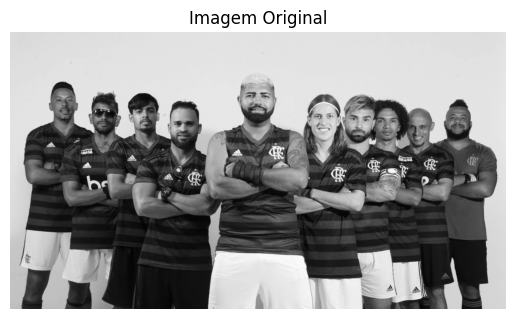

In [61]:
import matplotlib.pyplot as plt
from scipy.fft import dct
from PIL import Image

# Abrir imagem enviada
img = Image.open(filename).convert('L')  # escala de cinza
img = np.array(img, dtype=np.float64)

plt.imshow(img, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')
plt.show()

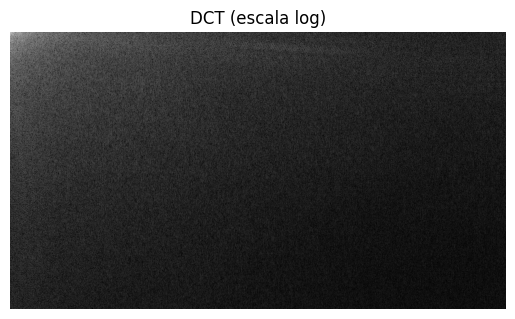

In [63]:
# Aplicar DCT 2D (linha + coluna)
def dct2(a):
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

dct_image = dct2(img)

plt.imshow(np.log(np.abs(dct_image) + 1), cmap='gray')
plt.title('DCT (escala log)')
plt.axis('off')
plt.show()

In [64]:
# Energia total
total_energy = np.sum(dct_image**2)

# Energia acumulada
flattened = np.abs(dct_image).flatten()
sorted_energy = np.sort(flattened**2)[::-1]

cumulative_energy = np.cumsum(sorted_energy)
cumulative_energy /= total_energy

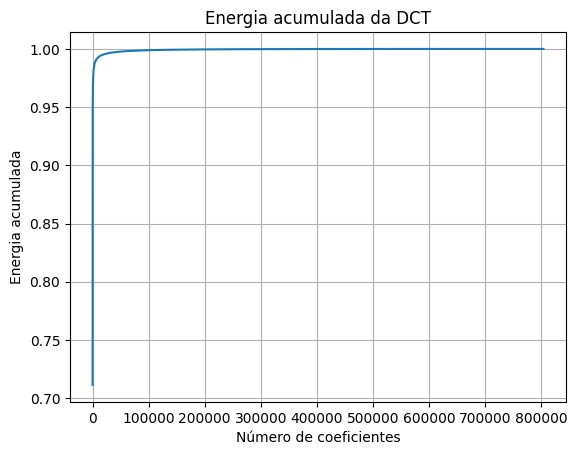

In [65]:
plt.plot(cumulative_energy)
plt.title('Energia acumulada da DCT')
plt.xlabel('Número de coeficientes')
plt.ylabel('Energia acumulada')
plt.grid()
plt.show()

In [66]:
thresholds = [0.9, 0.95, 0.99]

for t in thresholds:
    num_coeffs = np.argmax(cumulative_energy >= t)
    print(f"{t*100:.0f}% da energia em {num_coeffs} coeficientes ({num_coeffs/len(flattened)*100:.2f}%)")

90% da energia em 29 coeficientes (0.00%)
95% da energia em 219 coeficientes (0.03%)
99% da energia em 5577 coeficientes (0.69%)


In [ ]:
#Comentários
#A DCT concentra a maior parte da energia da imagem em poucos coeficientes de baixa frequência. Isso permite representar a imagem de forma eficiente com poucos dados, justificando o uso da DCT em técnicas de compressão como o JPEG.

In [ ]:
#Exercício Prático 5

In [67]:
from scipy.fft import dct, idct

def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

In [68]:
def compress_block(block, r):
    # Aplicar DCT
    dct_block = dct2(block)

    # Energia total
    energy = np.sum(dct_block**2)

    # Ordenar coeficientes por energia
    flat = dct_block.flatten()
    sorted_indices = np.argsort(np.abs(flat)**2)[::-1]

    compressed = np.zeros_like(flat)

    current_energy = 0
    total_energy = np.sum(np.abs(flat)**2)

    for idx in sorted_indices:
        compressed[idx] = flat[idx]
        current_energy += np.abs(flat[idx])**2

        if current_energy >= total_energy * (r / 100):
            break

    # Voltar ao formato original
    compressed_block = compressed.reshape(block.shape)

    # Reconstruir bloco
    return idct2(compressed_block)

In [69]:
def compress_image_blocks(img, block_size, r):
    h, w = img.shape
    compressed_img = np.zeros_like(img)

    num_coeffs = 0

    for i in range(0, h, block_size):
        for j in range(0, w, block_size):

            block = img[i:i+block_size, j:j+block_size]

            # garantir bloco completo
            if block.shape != (block_size, block_size):
                continue

            compressed_block = compress_block(block, r)

            compressed_img[i:i+block_size, j:j+block_size] = compressed_block

            num_coeffs += block_size * block_size  # total possível

    return compressed_img, num_coeffs

In [70]:
def mse(original, compressed):
    return np.mean((original - compressed)**2)

L=8, r=95% -> MSE: 333.2271


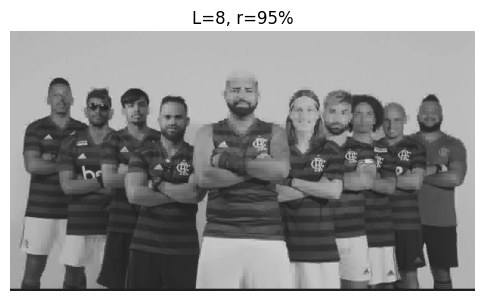

L=8, r=50% -> MSE: 612.7421


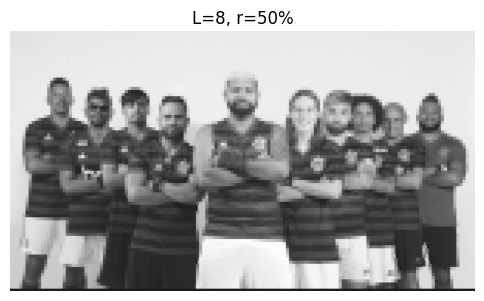

L=64, r=95% -> MSE: 3369.9456


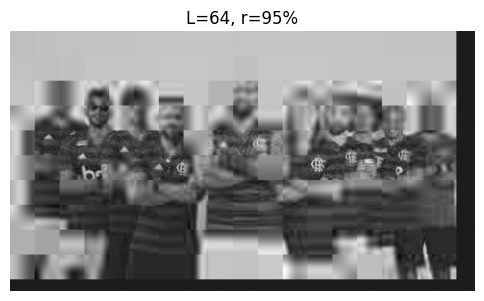

L=64, r=50% -> MSE: 5031.5121


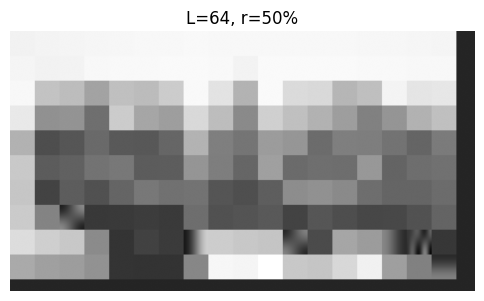

In [71]:
block_sizes = [8, 64]
compression_rates = [95, 50]

results = {}

for L in block_sizes:
    for r in compression_rates:
        compressed_img, num_coeffs = compress_image_blocks(img, L, r)

        error = mse(img, compressed_img)

        results[(L, r)] = error

        print(f"L={L}, r={r}% -> MSE: {error:.4f}")

        plt.figure(figsize=(6,6))
        plt.imshow(compressed_img, cmap='gray')
        plt.title(f'L={L}, r={r}%')
        plt.axis('off')
        plt.show()

In [ ]:
#Comentário
#A compressão por blocos utilizando a DCT mostrou-se eficiente na redução de dados mantendo boa qualidade visual, especialmente para blocos menores. Para blocos de tamanho 8×8, observou-se melhor preservação dos detalhes da imagem, com menor presença de artefatos visuais, comportamento semelhante ao padrão JPEG.
#Já para blocos maiores, como 64×64, a compressão introduziu distorções mais perceptíveis, com a formação de artefatos em blocos e perda significativa de qualidade visual. Isso ocorre devido à menor adaptação local da transformada em regiões maiores da imagem.
#Em relação à taxa de compressão, valores mais altos (95%) preservam melhor a qualidade da imagem, enquanto taxas mais baixas (50%) resultam em maior perda de informação e aumento do erro quadrático médio (MSE).
#Dessa forma, conclui-se que a escolha do tamanho do bloco e da taxa de compressão influencia diretamente na qualidade final da imagem, sendo blocos menores mais adequados para compressão eficiente com menor degradação visual.